In [1]:
print("Naga City is the best")

Naga City is the best


In [3]:
import os
os.getcwd()

'C:\\Users\\louis'

In [6]:
import os
os.listdir()

['(Git) DS project 1.ipynb',
 '.conda',
 '.condarc',
 '.continuum',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.lunarclient',
 '.matplotlib',
 '.mputils',
 '.Origin',
 '.QtWebEngineProcess',
 '.VirtualBox',
 '.vscode',
 '.vscode-cli',
 '3D Objects',
 'AB_NYC_2019.csv',
 'AB_NYC_2019.csv.zip',
 'anaconda3',
 'ansel',
 'AppData',
 'Application Data',
 'AppMods',
 'COMP517 GROUP REPORT DRAFT.ipynb',
 'Contacts',
 'Cookies',
 'curseforge',
 'Desktop',
 'Documents',
 'Downloads',
 'Employee_Performance.csv',
 'Favorites',
 'fileAB_NYC_2019.csv',
 'Lab10_Data.csv',
 'Lab10_PreLoad.ipynb',
 'Links',
 'Local Settings',
 'miktex-console.lock',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{d8ba0210-ea97-11f0-b4ab-e884a5867468}.TM.blf',
 'NTUSER.DAT{d8ba0210-ea97-11f0-b4ab-e884a5867468}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{d8ba0210-ea97-11f0-b4ab-e884a5867468}.TMContainer00000000000000000002.reg

In [10]:
import pandas as pd

#Print the first 5 rows of the data
df = pd.read_csv("fileAB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [13]:
#Price is our main variable so I will drop the columns with missing values
df = df.dropna(subset=['price'])

# For reviews_per_month, fill missing with 0 (means no reviews)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

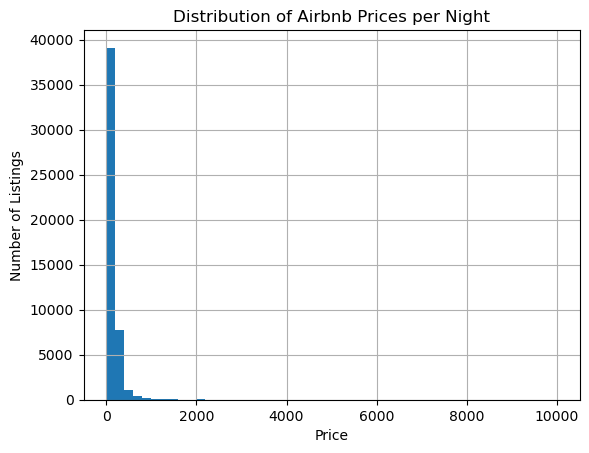

In [16]:
import matplotlib.pyplot as plt

plt.figure()
df['price'].hist(bins=50)
plt.title("Distribution of Airbnb Prices per Night")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.show()

Most Airbnb listings are priced under $200 per night, with a small number of very expensive outliers.

In [17]:
#Which room types are the most expensive?
df.groupby('room_type')['price'].mean().sort_values(ascending=False)

room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64

Entire homes/apt are the most expensive on average, followed by private rooms and then shared rooms being the cheapest. 

In [19]:
#Which neighbourhood groups are the priciest? 
df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)

neighbourhood_group
Manhattan        196.875814
Brooklyn         124.383207
Staten Island    114.812332
Queens            99.517649
Bronx             87.496792
Name: price, dtype: float64

Manhattan has the highest pricing when it comes to the neighbourhood group, followed by affordable options and the Bronx being the cheapest option. 

NEXT: Machine Learning Model to help predict Airbnb prices just from a few features.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

#More cleaning
df = df.dropna(subset=['price'])
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Select simple numeric features
features = df[['minimum_nights', 'number_of_reviews', 'availability_365']]
target = df['price']

features.head()

,minimum_nights,number_of_reviews,availability_365
0,1,9,365
1,1,45,355
2,3,0,365
3,1,270,194
4,10,9,0


In [27]:
#80% to train and 20% to test
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)


In [26]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [28]:
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
mae

97.35717705083816

We know it runs, but an MAE of 97 is high. This is because of the limited features we selected. 
- Minimum nights  
- Number of reviews  
- Availability over the year  
The model does not include location or room type, which strongly influence price.

**Next Steps:
- Add neighbourhood group and room type as features.
- Try simpler models such as Linear Regression for comparison.
- Perform feature engineering and tuning to improve performance.

In [29]:
# Add categorical features using one-hot encoding
df_encoded = pd.get_dummies(
    df[['minimum_nights', 'number_of_reviews', 'availability_365', 'room_type', 'neighbourhood_group']],
    drop_first=True
)

target = df['price']

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(df_encoded, target, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
mean_absolute_error(y_test, preds)

72.53949017344746

The final model achieved an MAE of approximately **$72.5 per night**, meaning that on average, the model’s predicted prices differ from the actual prices by around $72.5.

This improvement compared to the baseline model highlights the importance of including location and room type when predicting Airbnb prices.

**Limitations:**
- The model does not include detailed amenities or property features.
- Price variability remains high due to luxury listings and market dynamics.
- The dataset is from 2019 and may not reflect current trends.

**Next Steps:**
- Add more features (e.g. amenities, distance to city centre).
- Try alternative models (Linear Regression, Gradient Boosting).
- Perform hyperparameter tuning to further reduce error.

In [31]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=df_encoded.columns)
importances.sort_values(ascending=False).head(10)

availability_365                     0.395195
minimum_nights                       0.256522
number_of_reviews                    0.185509
room_type_Private room               0.083274
neighbourhood_group_Manhattan        0.028355
neighbourhood_group_Queens           0.017323
room_type_Shared room                0.017197
neighbourhood_group_Brooklyn         0.011934
neighbourhood_group_Staten Island    0.004693
dtype: float64

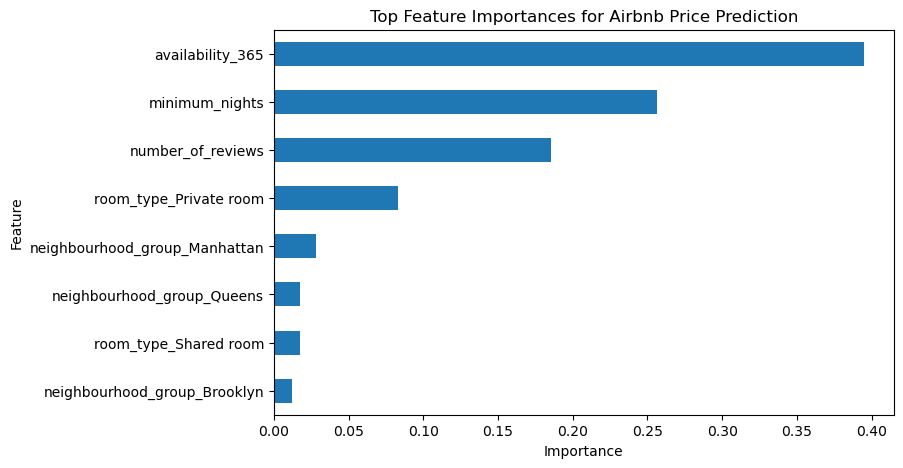

In [32]:
import matplotlib.pyplot as plt

top_features = importances.sort_values(ascending=False).head(8)

plt.figure(figsize=(8, 5))
top_features.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Feature Importances for Airbnb Price Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Availability and minimum nights were the most influential features in the model.

## Final Results & Conclusion

By incorporating additional features such as room type and neighbourhood group, the final model achieved a Mean Absolute Error (MAE) of approximately $72.5 per night, representing a significant improvement over the baseline model.

This demonstrates the importance of feature selection and domain knowledge when building machine learning models for real-world pricing problems.

Overall, this project shows an end-to-end data science workflow, including data cleaning, exploratory analysis, model building, evaluation, and interpretation.